In [2]:
import pointpats
import folium
import h3
import contextily as cx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from matplotlib import patches
from sklearn import cluster

url = "http://data.insideairbnb.com/czech-republic/prague/prague/2024-12-22/data/listings.csv.gz"

prag_Airbnb = pd.read_csv(url, index_col="id")
prag_Airbnb = gpd.GeoDataFrame(prag_Airbnb, geometry=gpd.points_from_xy(prag_Airbnb["longitude"], prag_Airbnb["latitude"]), crs=4326)
prag_Airbnb = prag_Airbnb.to_crs(epsg=5514)
prag_Airbnb.sample(n=8)

,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry
id,,,,,,,,,,,,,,,,,,,,,
9905699,https://www.airbnb.com/rooms/9905699,20241222060024,2024-12-22,previous scrape,Bright and Spacious Apartment in the Centre,Welcome to our lovely 115sqm (1240ft) apartmen...,The apartment is conveniently located just a 3...,https://a0.muscache.com/pictures/miso/Hosting-...,19156376,https://www.airbnb.com/users/show/19156376,...,4.90,4.93,NaN,f,1,1,0,0,0.92,POINT (-744090.589 -1044432.691)
4192947,https://www.airbnb.com/rooms/4192947,20241222060024,2024-12-22,city scrape,Perfect Studio with great view,The Apartment is situated next to the undergro...,There is a metro station at the front of the b...,https://a0.muscache.com/pictures/miso/Hosting-...,20967883,https://www.airbnb.com/users/show/20967883,...,4.71,4.63,NaN,f,12,12,0,0,0.45,POINT (-739645.161 -1042308.534)
39042013,https://www.airbnb.com/rooms/39042013,20241222060024,2024-12-22,city scrape,"Marilyn WiFi, AC, town 10' walk, Park free, Vi...",Just 5 minutes walking to Prague's river best ...,Close to the metro station Smíchovské nádraží ...,https://a0.muscache.com/pictures/miso/Hosting-...,292296048,https://www.airbnb.com/users/show/292296048,...,4.62,4.67,NaN,f,17,17,0,0,3.09,POINT (-743903.028 -1045837.221)
585222292163839239,https://www.airbnb.com/rooms/585222292163839239,20241222060024,2024-12-22,city scrape,Romantic apartment at Charles bridge with piano,Accommodation in romantic apartment at Charles...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,450120740,https://www.airbnb.com/users/show/450120740,...,4.94,4.84,NaN,f,2,2,0,0,0.98,POINT (-743632.83 -1042783.362)
1165846865757664119,https://www.airbnb.com/rooms/1165846865757664119,20241222060024,2024-12-22,city scrape,Dream city,"Perfect lively location with lots of shopping,...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,10121801,https://www.airbnb.com/users/show/10121801,...,4.50,4.25,NaN,f,3,3,0,0,0.61,POINT (-744152.342 -1044611.348)
1168125710001898851,https://www.airbnb.com/rooms/1168125710001898851,20241222060024,2024-12-22,city scrape,Nice Room In City Center [OP1],This is our guests' favourite part of Prague. ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,158561177,https://www.airbnb.com/users/show/158561177,...,4.86,4.79,NaN,t,40,7,33,0,9.79,POINT (-742251.336 -1043825.613)
1176624148887462796,https://www.airbnb.com/rooms/1176624148887462796,20241222060024,2024-12-22,city scrape,1BDR apt. in hip area • 100Mb • Netflix,Welcome to your Prague Days apartment.<br /><b...,"To see my recommendations for where to go, cli...",https://a0.muscache.com/pictures/miso/Hosting-...,65760645,https://www.airbnb.com/users/show/65760645,...,4.25,4.75,NaN,t,50,50,0,0,0.65,POINT (-741402.838 -1041488.09)
929074320453152403,https://www.airbnb.com/rooms/929074320453152403,20241222060024,2024-12-22,previous scrape,Studio Deluxe,This stylish place is perfect for families wit...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,468152769,https://www.airbnb.com/users/show/468152769,...,4.46,4.57,NaN,f,7,5,2,0,1.58,POINT (-745890.391 -1044698.297)


In [3]:
prag_Airbnb[["x", "y"]] = prag_Airbnb.get_coordinates()

(array([-760000., -755000., -750000., -745000., -740000., -735000.,
        -730000., -725000., -720000.]),
 [Text(-760000.0, 0, '−760000'),
  Text(-755000.0, 0, '−755000'),
  Text(-750000.0, 0, '−750000'),
  Text(-745000.0, 0, '−745000'),
  Text(-740000.0, 0, '−740000'),
  Text(-735000.0, 0, '−735000'),
  Text(-730000.0, 0, '−730000'),
  Text(-725000.0, 0, '−725000'),
  Text(-720000.0, 0, '−720000')])

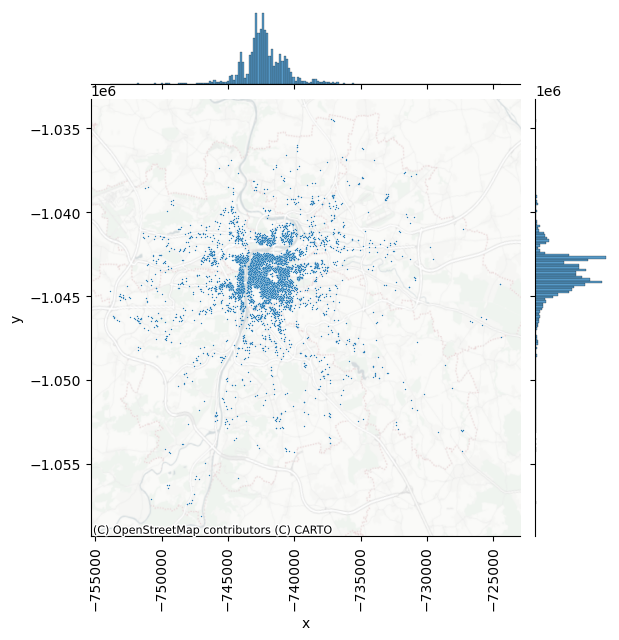

In [4]:
axs = sns.jointplot(x="x", y="y", data=prag_Airbnb, s=1)
cx.add_basemap(
    ax = axs.ax_joint, crs=prag_Airbnb.crs, source="CartoDB Positron No Labels"
)
plt.xticks(rotation=90)

In [5]:
for x, y in zip(prag_Airbnb["x"], prag_Airbnb["y"]):
    prag_Airbnb["h3_address"] = h3.latlng_to_cell(y, x, 9)

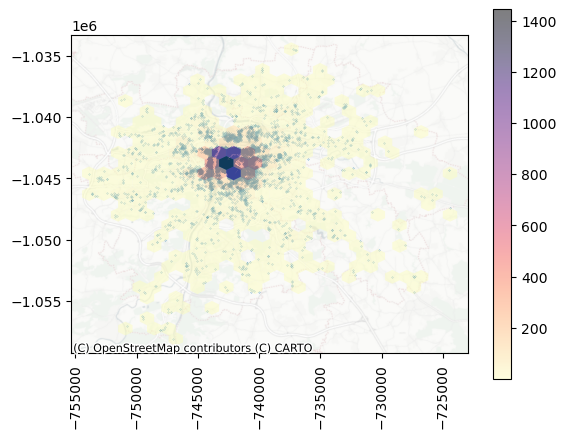

In [6]:
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)
hb = ax.hexbin(
    prag_Airbnb["x"],
    prag_Airbnb["y"],
    gridsize=25,
    linewidths=0,
    alpha=0.5,
    cmap="magma_r",
    mincnt=1,
)

cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="CartoDB Positron No Labels",
)
plt.colorbar(hb)
plt.xticks(rotation=90);

/Users/christopherchan/Proj/SPDS_KARLOVA/spatial-data-science-in-python-chrischank/.pixi/envs/default/lib/python3.14/site-packages/pointpats/kde.py:161: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_mesh, y_mesh, z, levels=levels, **kwargs)


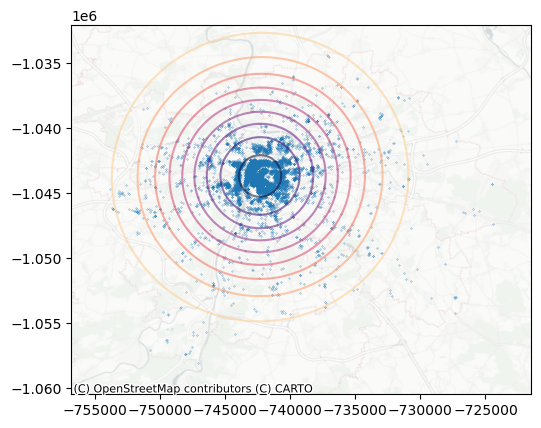

In [7]:
# KDE
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)
pointpats.plot_density(
    prag_Airbnb,
    bandwidth=5000,
    levels=9,
    alpha=0.55,
    cmap="magma_r",
    linewidth=1,
    ax=ax
)
cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="Carto DB Positron No Labels"
)

Airbnb patterns in praha seems to be in very regular concentric circles

In [8]:
# Centograph
mean_centre = pointpats.centrography.mean_center(prag_Airbnb)
med_centre = pointpats.centrography.euclidean_median(prag_Airbnb)

In [9]:
prag_Airbnb.columns

Index(['listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar

In [10]:
prag_Airbnb["price"] = prag_Airbnb["price"].str.replace("$", "").str.replace(",", "").astype("float32")

In [15]:
prag_Airbnb[["price", "review_scores_rating"]].describe()

,price,review_scores_rating
count,8.851000e+03,8990.000000
mean,5.076011e+03,4.727165
std,2.516177e+04,0.355862
min,2.260000e+02,1.000000
25%,2.086000e+03,4.650000
50%,3.143000e+03,4.820000
75%,4.900500e+03,4.930000
max,1.926446e+06,5.000000


In [43]:
weighted_price_mean = pointpats.centrography.weighted_mean_center(
    prag_Airbnb, prag_Airbnb["price"]
)
weighted_rating_mean = pointpats.centrography.weighted_mean_center(
    prag_Airbnb, prag_Airbnb["review_scores_rating"]
)
median_center = pointpats.centrography.euclidean_median(prag_Airbnb)
mean_center = pointpats.centrography.mean_center(prag_Airbnb)


ellipse_Airbnb = pointpats.centrography.ellipse(
    prag_Airbnb
)

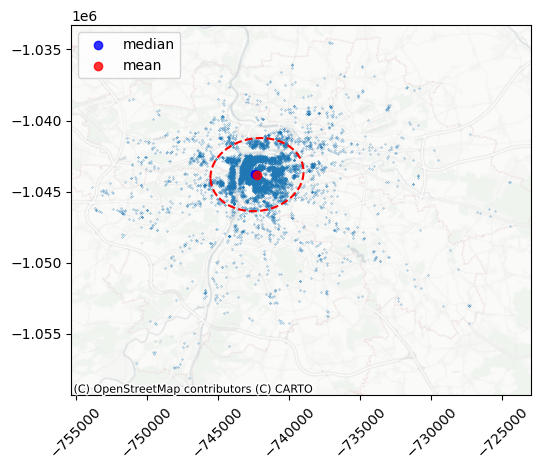

In [44]:
fig, ax = plt.subplots()
prag_Airbnb.plot(ax=ax, markersize=0.05)

ax.scatter(*median_center.xy, color="blue", marker="o", label="median", alpha=0.8)
ax.scatter(*mean_center.xy, color="red", marker="o", label="mean", alpha=0.8)
gpd.GeoSeries([ellipse_Airbnb.boundary], crs=prag_Airbnb.crs).plot(
    ax=ax,
    color="red",
    linestyle="--"
)


ax.legend(loc="upper left")

cx.add_basemap(
    ax=ax,
    crs=prag_Airbnb.crs,
    source="CartoDB Positron No Labels"
)
plt.xticks(rotation=45);